# 02 Descriptive Results

Replicate Figure 1-style inequality time series and Table 1-style HP-filtered correlations.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import get_paths, ensure_output_dirs
paths = get_paths()
ensure_output_dirs(paths)
print('Project root:', PROJECT_ROOT)
print('Original root:', paths.original_root)

Project root: C:\Users\asus\Desktop\Inequality_CGKS_replication_folder\python_replication
Original root: C:\Users\asus\Desktop\Inequality_CGKS_replication_folder\replication_folder


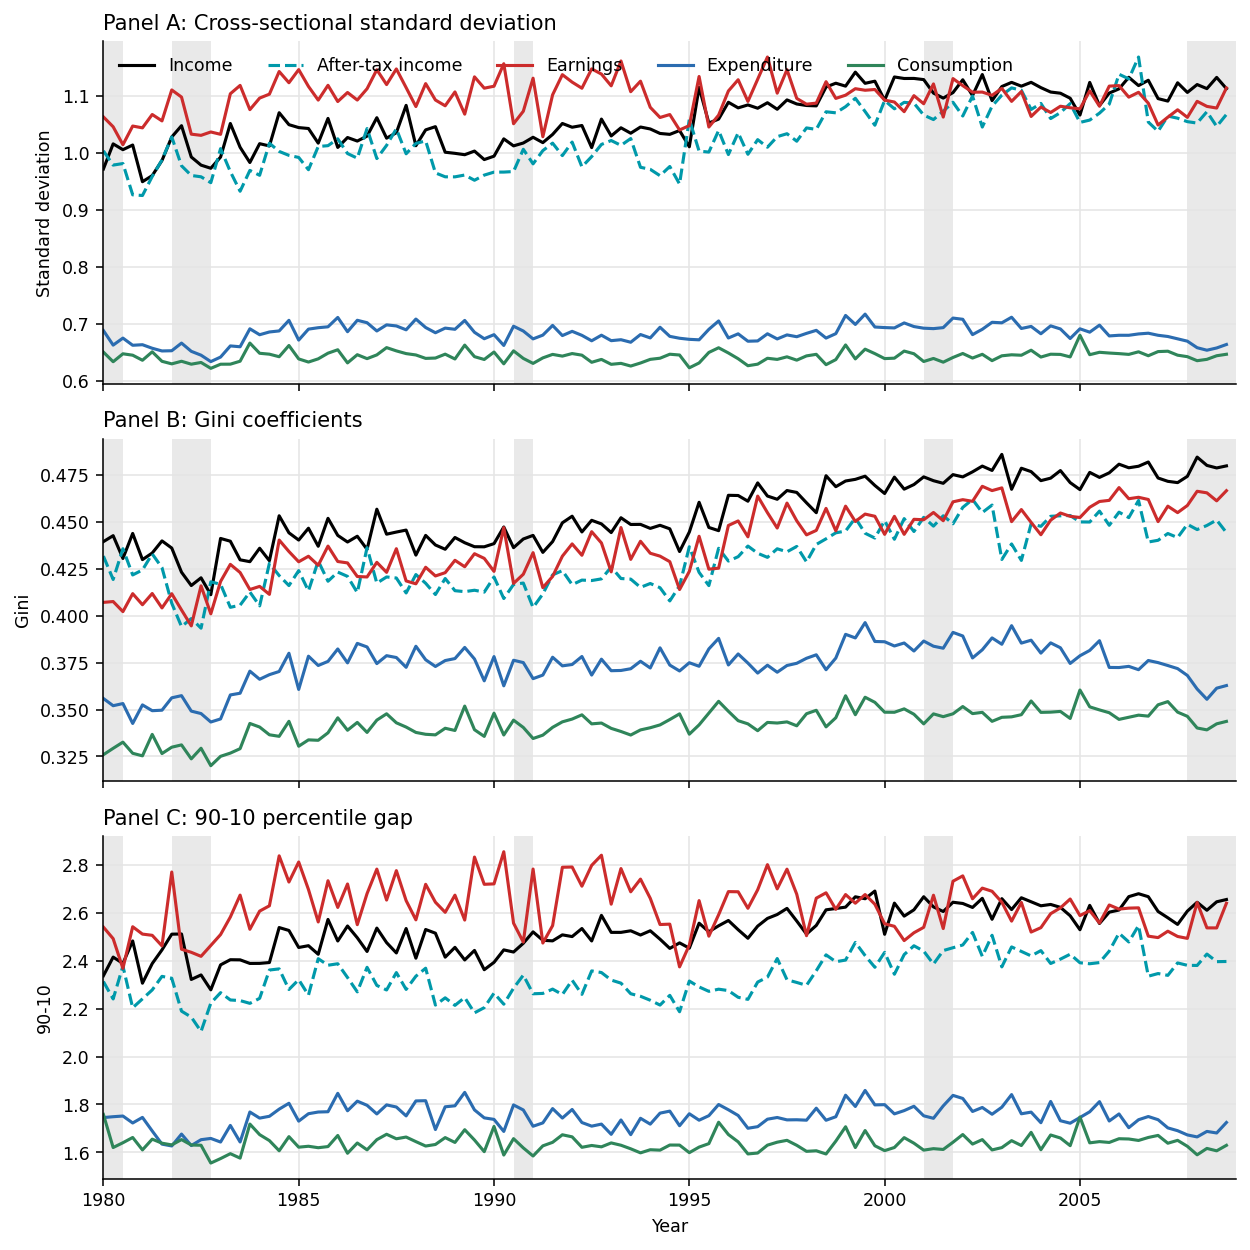

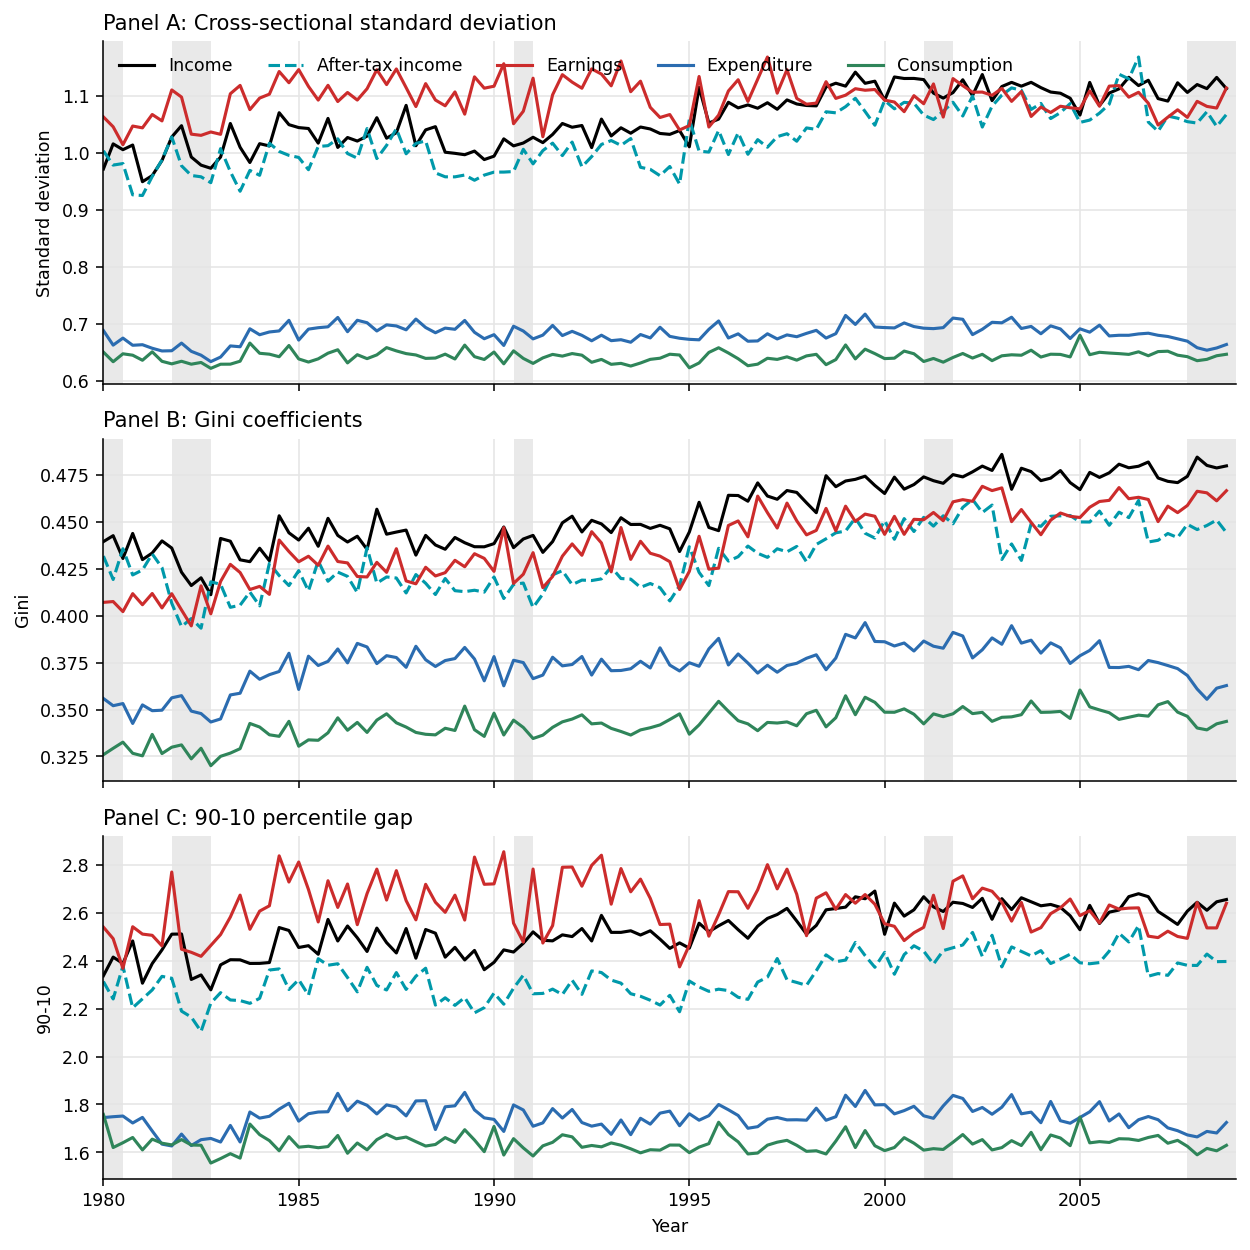

In [2]:
import pandas as pd
from src.data import load_cex_short, load_analysis_panel, hp_cycle
from src.plots import plot_descriptive_figure
from src.metrics import write_table

df = load_cex_short(paths)
fig = plot_descriptive_figure(df, paths.figures / 'figure1_descriptive_inequality.png')
fig

In [3]:
panel = load_analysis_panel(paths)
ineq_groups = {
    'SD': ['C_SD_LNYBTIMP2_SA','C_SD_LNSALARYIMP_SA','C_SD_LNTOTALEXP3_SA','C_SD_LNCONS_SA'],
    'Gini': ['C_GINI_YBTIMP2_SA','C_GINI_SALARYIMP_SA','C_GINI_TOTALEXP3_SA','C_GINI_CONS_SA'],
    '90-10': ['C_P9010_LNYBTIMP2_SA','C_P9010_LNSALARYIMP_SA','C_P9010_LNTOTALEXP3_SA','C_P9010_LNCONS_SA'],
}
macro = {'Inflation': 'dlnPGDP', 'Unemployment': 'UE', 'FFR': 'FFR'}
work = panel.copy()
for c in set(sum(ineq_groups.values(), []) + list(macro.values())):
    work[c + '_cycle'] = hp_cycle(work[c])
rows = []
for macro_name, macro_col in macro.items():
    for measure, cols in ineq_groups.items():
        row = {'macro': macro_name, 'measure': measure}
        for label, col in zip(['Income','Earnings','Expenditure','Consumption'], cols):
            tmp = work[[macro_col + '_cycle', col + '_cycle']].dropna()
            row[label] = tmp[macro_col + '_cycle'].corr(tmp[col + '_cycle'])
        rows.append(row)
table1 = pd.DataFrame(rows)
write_table(table1, paths.tables / 'table1_hp_correlations.csv')
table1

,macro,measure,Income,Earnings,Expenditure,Consumption
0,Inflation,SD,-0.046820,-0.003959,-0.005020,0.103132
1,Inflation,Gini,-0.100825,-0.193841,-0.058710,0.052562
2,Inflation,90-10,0.013411,0.041386,0.005749,0.053291
3,Unemployment,SD,0.007350,0.017457,-0.315999,-0.250664
4,Unemployment,Gini,0.191626,0.379253,-0.249526,-0.243294
5,Unemployment,90-10,-0.014578,0.052949,-0.220186,-0.249837
6,FFR,SD,-0.120741,-0.073555,0.073930,0.138178
7,FFR,Gini,-0.204224,-0.334162,0.023680,0.106046
8,FFR,90-10,-0.064524,-0.131026,0.017341,0.163976


## Deviation Note

The table is a Python reconstruction of the Table 1 logic from `step601`: HP-filter each series with lambda 1600, then compute correlations. Minor numerical differences can arise from Stata and statsmodels HP-filter endpoint conventions.